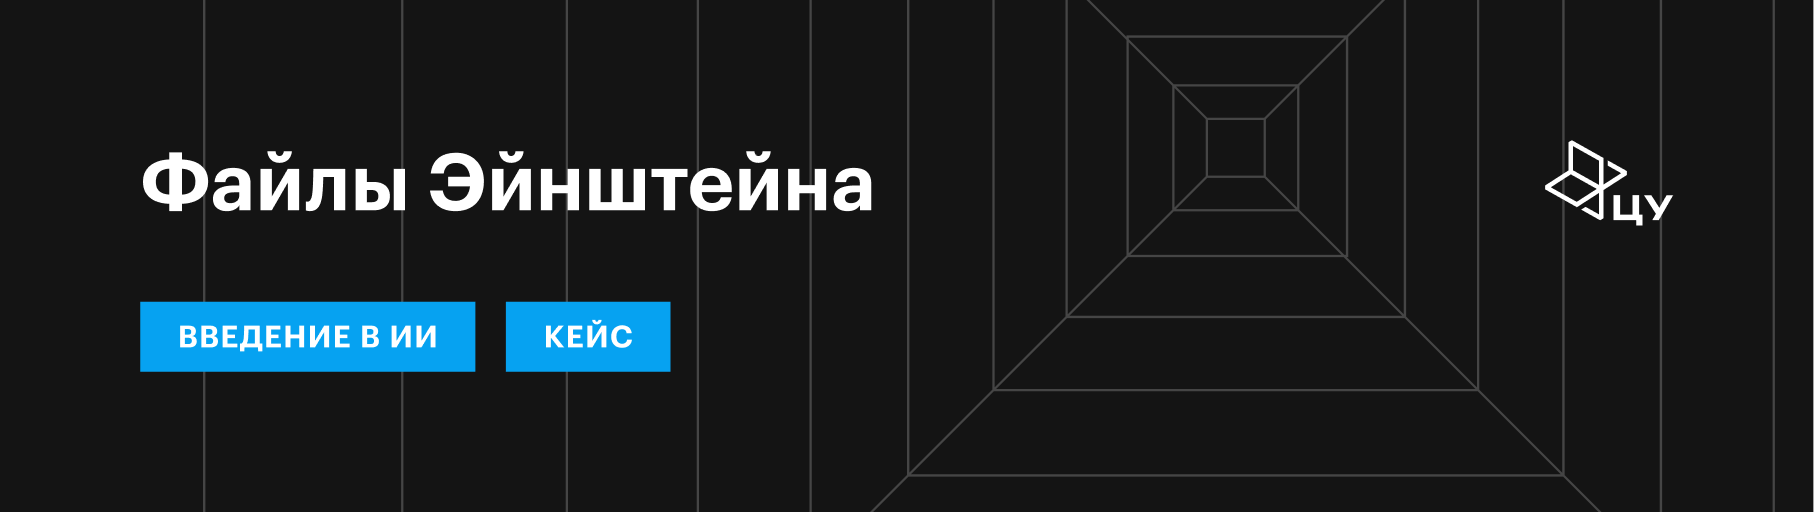

# Легенда

Ты работаешь в компании Х, которая занимается исследованием и сортировкой документов.
Недавно к тебе в руки попал ранее скрытый от глаз общественности материал *«Файлы Эйнштейна»*, содержащий тексты писем, написанных от руки великим учёным.

Один стажёр уже отсканировал файлы и начал вручную их расшифровывать. Однако старый офисный сканер оставил ошибки и артефакты на текстах, а вкупе с неразборчивым почерком Альберта Эйнштейна эта задача оказалась невыполнимой.

Поэтому твой начальник обратился к тебе с просьбой: «Сделайте так, чтобы компьютер сам всё прочитал. И чтобы потом можно было найти слово «бомба» или «антивселенная»: мало ли что там у этого Эйнштейна было на уме».

**Задача:** создать нейросетевую модель OCR (оптическое распознавание символов), которая сможет распознавать рукописный текст Эйнштейна с максимальной точностью.

# Требования к решению

Поскольку это учебный проект, вводятся следующие технические ограничения.

* **Ограничение по размеру модели:** решение должно корректно работать в Google Colab. Использовать несколько Google-аккаунтов для увеличения квоты на Т4 для экспериментов с архитектурой не запрещено.

* **Воспроизводимость:** весь код должен выполняться последовательно с первого раза. Обязательно фиксируй random_seed, а также сохраняй веса моделей и логируй эксперимент.

**Необходимые этапы решения**

1. *Обработка данных*. Внимательно изучи данные в датасете `einstein_files`. Предложи способ выделения символов из текста. Подумай, можно ли применять модель к сырым данным или нужно провести некоторые манипуляции.


2. *Выбор модели*. Напиши свою модель классификации рукописных букв английского алфавита или выбери предобученную.


3. *Решение задачи распознавания символов*. Обучение выбранной модели на датасете. Опиши, как осуществлялись подбор гиперпараметров, выбор метрики и валидация.

4. *Применение модели*. Финальный этап решения: объедини две основные составляющие в одну (выделение символов из изображения, их обработка моделью распознавания символов, составление полного текста). Результаты OCR будут проверяться по метрикам accuracy.

# Система оценивания

Решение оценивается по трём параметрам.
* **Работа с данными [4 балла].** Оценка ставится в соответствии с тем, насколько подробно была произведена работа с данными. Визуализации, предобработка и очистка/обогащение датасета будут плюсом.

* **Решение задачи [4 балла].** Оценка ставится не за итоговые метрики (для простых моделей их значение может быть небольшим), а за то, насколько качественно были проделаны эксперименты в рамках выбранной модели. То есть если в решении используется примитивная модель, получающая низкие метрики, но она обучена с разными гиперпараметрами и приёмами так, что из её качества выжимается максимум, то это решение будет оценено в полный балл.

* **Оформление [2 балла].** Хочется, чтобы написанный код читался как хорошая книга. Для этого мы добавляем баллы за оформление, если в коде появляются визуализации, комментарии к коду и сопроводительный текст.

# Данные

Ниже написан код для скачивания датасета `einstien_files`, который содержит 46 изображений отсканированных документов с рукописным текстом на английском языке.

In [1]:
!gdown 1gMlho_Jrzuy2Lt-8rKZa8gr7jo_RiMUQ
!unzip -q /content/einstein_files.zip
!rm /content/einstein_files.zip

Downloading...
From: https://drive.google.com/uc?id=1gMlho_Jrzuy2Lt-8rKZa8gr7jo_RiMUQ
To: /content/einstein_files.zip
100% 4.81M/4.81M [00:00<00:00, 163MB/s]
replace einstein_files/file_20.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [1]:
!ls einstein_files

file_0.png   file_17.png  file_24.png  file_31.png  file_39.png  file_4.png
file_10.png  file_18.png  file_25.png  file_32.png  file_3.png	 file_5.png
file_11.png  file_19.png  file_26.png  file_33.png  file_40.png  file_6.png
file_12.png  file_1.png   file_27.png  file_34.png  file_41.png  file_7.png
file_13.png  file_20.png  file_28.png  file_35.png  file_42.png  file_8.png
file_14.png  file_21.png  file_29.png  file_36.png  file_43.png  file_9.png
file_15.png  file_22.png  file_2.png   file_37.png  file_44.png
file_16.png  file_23.png  file_30.png  file_38.png  file_45.png


# Твой код

In [2]:
import os
import copy

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import EMNIST

### вспомогательные функции + получение изображения

In [3]:
def plot_images(images, titles=None, fontsize=20, figsize=(10, 10), save_path=None):

    n_images = len(images)

    fig, axs = plt.subplots(1, n_images, figsize=figsize)

    for i in range(n_images):
        img = images[i]

        # Переводит всё в numpy
        if isinstance(img, torch.Tensor):
            if len(img.shape)==4:
                img = img[0]
            if img.shape[0] == 1:
                img = img[0]
            else:
                img = img.permute(1, 2, 0)
            arr = img.numpy()
        else: # Считаем, что иначе numpy-массив
            if img.dtype == np.uint8:
                img = img / 255
            arr = img.astype(np.float32)

        # Визуализация
        axs[i].imshow(arr, cmap=("gray" if arr.ndim == 2 else None))
        axs[i].axis("off")

        # Названия
        if titles:
            axs[i].set_title(titles[i], fontsize=fontsize)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

def hist_features(images, bins=16, value_range=(0.0, 1.0)):
    """Строит нормированные гистограммные признаки для набора изображений."""
    features = []
    for img in images:
        hist, _ = np.histogram(img, bins=bins, range=value_range)
        hist = hist.astype(np.float32)
        hist = hist / hist.sum()
        features.append(hist)
    return np.array(features)

In [4]:
img = Image.open('einstein_files/file_0.png')
img = np.array(img)
median_blur = cv2.medianBlur(img, 3)

In [5]:
median_blur.shape

(675, 580)

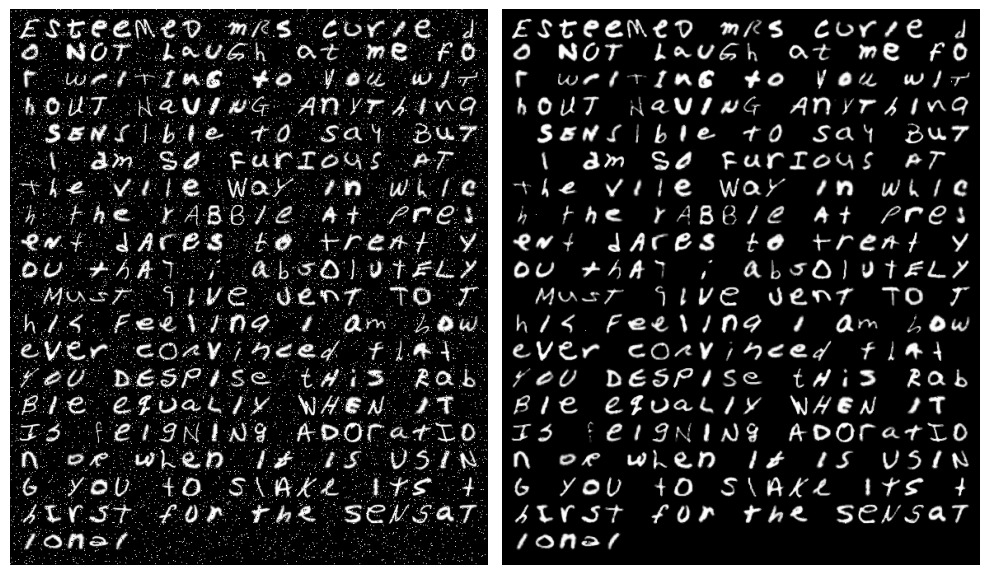

In [6]:
plot_images([img, median_blur])

In [7]:
def get_array(path):
    img = Image.open(path)
    img = np.array(img)
    median_blur = cv2.medianBlur(img, 3)
    return median_blur

### делим на буквы

In [8]:
def sort_comp(components, y_thresh=10):
    components = sorted(components, key=lambda c: c[1][1])

    lines = []
    current_line = [components[0]]

    for comp in components[1:]:
        _, (x, y, w, h) = comp
        _, (px, py, pw, ph) = current_line[-1]

        if abs(y - py) < y_thresh:
            current_line.append(comp)
        else:
            lines.append(current_line)
            current_line = [comp]

    lines.append(current_line)

    for line in lines:
        line.sort(key=lambda c: c[1][0])

    ans = []
    for line in lines:
        ans.extend(line)

    space = []
    for i in range(1, len(ans)):
        _, (x, y, w, h) = ans[i]
        _, (px, py, pw, ph) = ans[i - 1]
        if abs(y - py) < y_thresh:
            if x - px - pw >= 20:
                space.append(i - 1)
        else:
            if (x + 580) - (px + pw) >= 50:
                space.append(i - 1)
    return ans, space

In [41]:
def get_comp(img):
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(img, connectivity=8)

    components = []

    for i in range(1, n_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        if area < 20:
            continue

        crop = img[y:y+h, x:x+w]

        components.append((crop, (x, y, w, h)))
    components, space = sort_comp(components)
    processed = []

    for crop, bbox in components:
        norm = to_emnist(crop)
        processed.append(norm)

    return processed, space

In [10]:
n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(median_blur, connectivity=8)

In [11]:
components = []

for i in range(1, n_labels):
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    if area < 20:
        continue

    crop = median_blur[y:y+h, x:x+w]

    components.append((crop, (x, y, w, h)))

In [12]:
components, space = sort_comp(components)

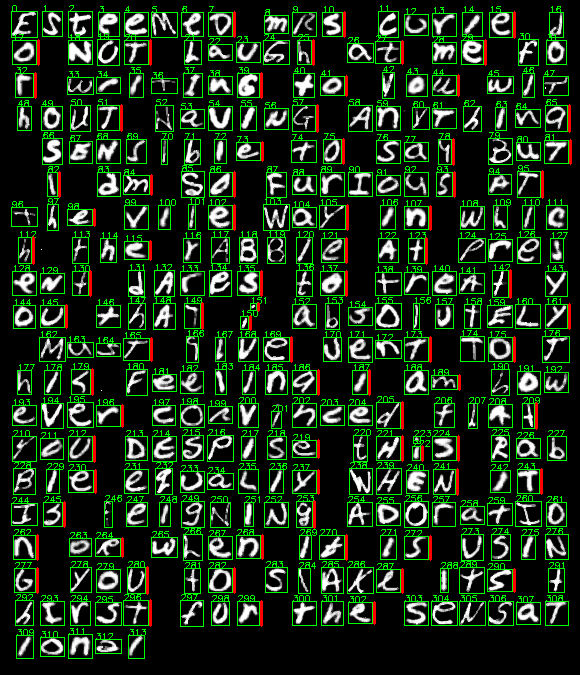

In [13]:
from google.colab.patches import cv2_imshow

vis = cv2.cvtColor(median_blur, cv2.COLOR_GRAY2BGR)

for i, comp in enumerate(components):
    x, y, w, h = comp[1]

    cv2.rectangle(vis, (x, y), (x+w, y+h), (0,255,0), 1)
    cv2.putText(vis, str(i), (x, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0,255,0), 1)

    if i in space:
        line_x = x + w + 2
        cv2.line(vis,
                 (line_x, y),
                 (line_x, y + h),
                 (0, 0, 255), 2)

cv2_imshow(vis)

In [14]:
def to_emnist(img, size=28):
    h, w = img.shape

    scale = size / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)

    resized = cv2.resize(img, (new_w, new_h))

    canvas = np.zeros((size, size), dtype=np.uint8)

    y_offset = (size - new_h) // 2
    x_offset = (size - new_w) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return canvas

processed = []

for crop, bbox in components:
    norm = to_emnist(crop)
    processed.append(norm)

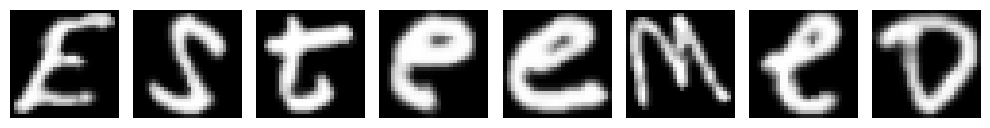

In [15]:
plot_images(processed[:8])

### обучение модели

In [16]:
class FixEMNIST:
    def __call__(self, img):
        return torch.rot90(img, k=3, dims=(1, 2)).flip(2)

transform = transforms.Compose([
    transforms.ToTensor(),
    FixEMNIST(),
])

train_ds = EMNIST(
    root="./data",
    split="letters",
    train=True,
    download=True,
    transform=transform,
)

test_ds = EMNIST(
    root="./data",
    split="letters",
    train=False,
    download=True,
    transform=transform,
)

In [17]:
BATCH_SIZE = 2048
EPOCHS = 10
LR = 1e-3
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

num_classes = len(train_ds.classes)
print("Classes:", num_classes)
print("First classes:", train_ds.classes[:20])

Classes: 27
First classes: ['N/A', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's']


In [19]:
train_loader.batch_size

2048

In [20]:
class EMNISTNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = EMNISTNet(num_classes=num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)


In [21]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if is_train:
            loss.backward()
            optimizer.step()

        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total_samples += x.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

best_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, test_loader, optimizer=None)
    scheduler.step()

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

print(f"Best val_acc = {best_acc:.4f}")

os.makedirs("checkpoints", exist_ok=True)
torch.save(
    {
        "model_state_dict": best_state,
        "num_classes": num_classes,
        "classes": train_ds.classes,
    },
    "checkpoints/emnist_cnn_best.pt"
)

print("Saved: checkpoints/emnist_cnn_best.pt")





Epoch 01/10 | train_loss=0.7101 train_acc=0.7832 | val_loss=0.3154 val_acc=0.9007
Epoch 02/10 | train_loss=0.2602 train_acc=0.9152 | val_loss=0.2085 val_acc=0.9298
Epoch 03/10 | train_loss=0.2074 train_acc=0.9314 | val_loss=0.2068 val_acc=0.9299
Epoch 04/10 | train_loss=0.1849 train_acc=0.9380 | val_loss=0.1803 val_acc=0.9394
Epoch 05/10 | train_loss=0.1575 train_acc=0.9464 | val_loss=0.1724 val_acc=0.9411
Epoch 06/10 | train_loss=0.1465 train_acc=0.9494 | val_loss=0.1637 val_acc=0.9439
Epoch 07/10 | train_loss=0.1394 train_acc=0.9516 | val_loss=0.1650 val_acc=0.9441
Epoch 08/10 | train_loss=0.1332 train_acc=0.9531 | val_loss=0.1624 val_acc=0.9434
Epoch 09/10 | train_loss=0.1214 train_acc=0.9570 | val_loss=0.1558 val_acc=0.9463
Epoch 10/10 | train_loss=0.1154 train_acc=0.9593 | val_loss=0.1577 val_acc=0.9457
Best val_acc = 0.9463
Saved: checkpoints/emnist_cnn_best.pt


In [22]:
model.load_state_dict(best_state)
model.eval()

EMNISTNet(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=27,

### инференс

In [23]:
x = np.stack(processed)          # [N, 28, 28]
x = x.astype(np.float32) / 255.0 # нормализация
x = torch.from_numpy(x)          # [N, 28, 28]
x = x.unsqueeze(1)               # [N, 1, 28, 28]

x = x.to(DEVICE)

x.shape

torch.Size([314, 1, 28, 28])

In [24]:
logits = model(x)
preds = logits.argmax(dim=1)

In [25]:
text = ""
for i, logit in enumerate(preds):
    text += train_ds.classes[logit]
    if i in space:
        text += " "

In [26]:
text

'esteemed mrs curie jo not laugh at me for writing to vou without jauing anything sensibie to say but i am so furious pt the vile way in which the yabbie at prejent dares to treat you that i o absolutely must give uent to this feeiing i am iowever convioced tiat you despise th i qj rabbie equaliy when it is ieigning adoration or when ib is using you to slakl its thirst fur the sensationai'

In [27]:
def get_text(comp, model, space):
    x = np.stack(comp).astype(np.float32) / 255.0
    x = torch.from_numpy(x).unsqueeze(1).to(DEVICE)

    logits = model(x)
    preds = logits.argmax(dim=1)

    text = ""
    for i, logit in enumerate(preds):
        text += train_ds.classes[logit]
        if i in space:
            text += " "
    return text

# Итог

В этом разделе мы подведём итоги обработки данных и обучения модели OCR. Для этого мы используем две метрики — **Character Error Rate** (CER) и **Word Error Rate** (WER).

1. CER вычисляется как расстояние Левенштейна (то есть количество замен символов, необходимое для перевода одной строки в другую) между исходным текстом и распознанным, делённое на количество символов.

2. WER вычисляется как процент совпадающих слов.

In [28]:
!pip install Levenshtein

In [29]:
from Levenshtein import distance

def character_error_rate(pred_text, real_text):
    """Расстояние Левенштейна"""
    return distance(pred_text, real_text) / len(real_text)

In [30]:
def word_error_rate(pred_text, real_text):
    """Процент слов, распознанных с ошибкой"""
    pred_words = pred_text.split()
    true_words = real_text.split()

    if len(true_words) == 0:
        return 0 if len(pred_words) == 0 else 1.0

    errors = sum(1 for p, t in zip(pred_words, true_words) if p != t)
    errors += abs(len(pred_words) - len(true_words))

    return errors / len(true_words)

Напиши функцию для обработки файлов Эйнштейна. Она должна принимать на вход датасет `epstein_files` (чтение данных и их обработку ты выбираешь и реализовываешь самостоятельно) и твою модель OCR `model`. На выходе — распознанный текст.

In [38]:
def process(einstein_files, model):
    pred_text = ""
    for i in range(46):
        img = get_array(f'einstein_files/file_{i}.png')
        comp, space = get_comp(img)
        text = get_text(comp, model, space)
        pred_text += text
        pred_text += ' '

    return pred_text

In [42]:
pred_text = process("", model)

In [43]:
pred_text

'esteemed mrs curie jo not laugh at me for writing to vou without jauing anything sensibie to say but i am so furious pt the vile way in which the yabbie at prejent dares to treat you that i o absolutely must give uent to this feeiing i am iowever convioced tiat you despise th i qj rabbie equaliy when it is ieigning adoration or when ib is using you to slakl its thirst fur the sensationai l musr teli you how much e i aave come to admlre your spirit gcist your crepxivity and your honustv i consider myseif lucky to have made your personai acauaintance in jyusseis anvone other tham thofe reptiies is certainly happy now as before that we have eminent people llke you and aiso langevin amolg us reql peupie wirkliche menschen wiith wnom one feels privileged to be in contqct if the rabble cont i anues to occupy itself wilh tou then slmplx do not tead thjt swiii rather leave it to the reptiie for whom it is been fabrlcated with most frienjly regards to you iangevin and jean perrin yours uery tr

Прочитай текстовый файл с реальным текстом файлов Эйнштейна и оцени качество модели с помощью метрик выше.

**ВНИМАНИЕ.** Данный файл в целях академической честности может быть прочтён и использован только в части кода снизу.

In [34]:
!gdown 1hF7HHyIROhPoVOzQnBiqjfYtJ6v4raJC

Downloading...
From: https://drive.google.com/uc?id=1hF7HHyIROhPoVOzQnBiqjfYtJ6v4raJC
To: /content/top_secret.txt
100% 15.4k/15.4k [00:00<00:00, 44.0MB/s]


In [35]:
with open('top_secret.txt', 'r', encoding='utf-8') as file:
    real_text = file.read().lower()

In [44]:
wer = word_error_rate(pred_text, real_text)
cer = character_error_rate(pred_text, real_text)
print(f"WER = {wer}")
print(f"CER = {cer}")

WER = 0.9974637681159421
CER = 0.07819304517387066


**Выводы:** опиши, как ты пришёл(-ла) к решению, какие модели использовались, как проходил подбор гиперпараметров, как работал(а) с данными, с какими проблемами столкнулся(ась) и прочее.

сначала я посмотрел на листы файлов эйштейна, увидел, что шум похож на salt and pepper, убрал его с помощью median blur, дальше разделил на буквы поиском компонент, нашел пробелы, чтобы впоследствии закинуть их в текст. дальше обучил модель на датасете EMNIST, в котором 28х28 буквы как в MNIST. ну и заинференсил. сложнее всего было написать все эти функции. результат получился нормальный. но wer поехал к 1 из-за того что где-то есть задвоение слова или плохой пробел, из-за чего и получились такие плохие метрики
